<a href="https://colab.research.google.com/github/rubyratcha-19/GE338_lab4/blob/main/lab4_6606614805.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Lab 4: Geographic Modeling**
**สร้างและตรวจสอบแบบจำลองเชิงพื้นที่**

รัชชานนท์ สุรินทร์ 6606614805

## **ความเครียดจากความร้อนในพื้นที่เมืองจังหวัดนนทบุรี ปี2020 (Urban Heat Stress)**

**ภารกิจที่ 1: กำหนดกรอบแนวคิด (Conceptual Framework)**



ปัจจัยที่กำหนด
1) LST (Land Surface Temperature)
- แหล่งข้อมูล: MODIS
- แนวคิด: เมืองสะสมความร้อนทำให้ UHI สูง

2) Air Temperature (ERA5)
- อุณหภูมิอากาศที่ระดับ 2 เมตร
- แนวคิด: ส่งผลต่อ thermal comfort โดยตรง

3) NDBI (Built-up Index)
- สูตร:
  NDBI = (SWIR - NIR) / (SWIR + NIR)
- แนวคิด: พื้นที่เมืองจะความร้อนสูง

4) NDVI (Vegetation Index)
- สูตร:
  NDVI = (NIR - RED) / (NIR + RED)
- แนวคิด: พืชช่วยลดอุณหภูมิ

5) NDWI (Water Index)
- สูตร:
  NDWI = (GREEN - NIR) / (GREEN + NIR)
- แนวคิด: น้ำช่วยลดอุณหภูมิ

LST     =  0.40   
AirTemp =  0.20   
NDBI    =  0.20   
NDVI    = -0.15   พืชช่วยลดความร้อน

NDWI    = -0.05   น้ำช่วยลดความร้อน

แนวคิดที่ใช้อ้างอิง:

Urban Heat Island (UHI)

A global map of Local Climate Zones (https://lcz-generator.rub.de/global-lcz-map)

MONITORING URBAN HEAT ISLAND THROUGH GOOGLE EARTH ENGINE:
POTENTIALITIES AND DIFFICULTIES IN DIFFERENT CITIES OF THE UNITED STATES (https://www.researchgate.net/publication/324847807_MONITORING_URBAN_HEAT_ISLAND_THROUGH_GOOGLE_EARTH_ENGINE_POTENTIALITIES_AND_DIFFICULTIES_IN_DIFFERENT_CITIES_OF_THE_UNITED_STATES)

Dataset: UHII (Urban Heat Island Intensity) จาก GEE

- เปรียบเทียบ UHS vs UHII
- ใช้ Pearson Correlation

step 1 — INSTALL + AUTH

In [4]:
!pip install earthengine-api geemap matplotlib

import ee
import geemap
import matplotlib.pyplot as plt

ee.Authenticate()
ee.Initialize(project='inlaid-reactor-457503-u6')

Map = geemap.Map()

2 — AOI (นนทบุรี)

In [5]:
thai = ee.FeatureCollection('FAO/GAUL/2015/level1')
roi = thai.filter(ee.Filter.eq('ADM1_NAME', 'Nonthaburi'))

Map.centerObject(roi, 10)
Map.addLayer(roi, {}, 'ROI')

Map

Map(center=[13.921145528717187, 100.3968564546895], controls=(WidgetControl(options=['position', 'transparent_…

3 — Sentinel-2 (RGB)

In [6]:
def maskS2(image):
    scl = image.select('SCL')
    mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9))
    return (image.updateMask(mask)
            .select(['B2','B3','B4','B8','B11'])
            .copyProperties(image, image.propertyNames()))

s2 = (ee.ImageCollection('COPERNICUS/S2_SR')
      .filterBounds(roi)
      .filterDate('2020-01-01', '2020-12-31')
      .map(maskS2)
      .median()
      .clip(roi))

Map.addLayer(s2, {'bands':['B4','B3','B2'], 'min':0, 'max':3000}, 'RGB')

Map

Map(center=[13.921145528717187, 100.3968564546895], controls=(WidgetControl(options=['position', 'transparent_…

**ภารกิจที่ 2: สร้างและรัน Spatial Model**

1. Normalize (Min-Max)
X_norm = (X - X_min) / (X_max - X_min)

เหตุผล คือทำให้ทุก factor อยู่ในช่วง 0–1
ป้องกัน bias จาก scale ที่ต่างกัน

2. สมการโมเดล
UHS = 0.4(LST) + 0.2(AirTemp) + 0.2(NDBI) - 0.15(NDVI) - 0.05(NDWI)

Interpretation
ค่าใกล้ 1 คือ ร้อนมาก
ค่าใกล้ 0 คือ เย็น

3. Threshold

- ค่า UHS น้อยกว่า 0.33 ระดับ Low (ความร้อนต่ำ)
- ค่า UHS อยู่ระหว่าง 0.33 ถึง 0.66 ระดับ Medium (ความร้อนปานกลาง)
- ค่า UHS มากกว่า 0.66 ระดับ High (ความร้อนสูง)

4. Layer ที่แสดง:
- NDVI
- NDWI
- NDBI
- LST
- Air Temperature
- UHS (Final)

Visualization ใช้ color scale: Green → Red


4 — NDVI / NDWI / NDBI

In [7]:
ndvi = s2.normalizedDifference(['B8','B4']).rename('NDVI')
ndwi = s2.normalizedDifference(['B3','B8']).rename('NDWI')
ndbi = s2.normalizedDifference(['B11','B8']).rename('NDBI')

Map.addLayer(ndvi, {'min':0,'max':1,'palette':['white','green']}, 'NDVI')
Map.addLayer(ndwi, {'min':-1,'max':1,'palette':['brown','blue']}, 'NDWI')
Map.addLayer(ndbi, {'min':-1,'max':1,'palette':['white','red']}, 'NDBI')

Map

Map(center=[13.921145528717187, 100.3968564546895], controls=(WidgetControl(options=['position', 'transparent_…

5 — LST

In [8]:
lst = (ee.ImageCollection('MODIS/006/MOD11A2')
       .filterBounds(roi)
       .filterDate('2020-01-01','2020-12-31')
       .select('LST_Day_1km')
       .mean()
       .multiply(0.02)
       .subtract(273.15)
       .rename('LST')
       .clip(roi))

Map.addLayer(lst, {'min':25,'max':45,'palette':['blue','yellow','red']}, 'LST')

Map

Map(center=[13.921145528717187, 100.3968564546895], controls=(WidgetControl(options=['position', 'transparent_…

6 — Air Temperature

In [9]:
air = (ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
       .select('temperature_2m')
       .filterDate('2020-01-01','2020-12-31')
       .mean()
       .subtract(273.15)
       .rename('Air')
       .clip(roi))

Map.addLayer(air, {'min':20,'max':35,'palette':['blue','green','red']}, 'Air Temp')

Map

Map(center=[13.921145528717187, 100.3968564546895], controls=(WidgetControl(options=['position', 'transparent_…

7 — Normalize

In [10]:
def normalize(img, name):
    stats = img.reduceRegion(
        reducer=ee.Reducer.minMax(),
        geometry=roi,
        scale=1000,
        maxPixels=1e13
    )
    minv = ee.Number(stats.get(name + '_min'))
    maxv = ee.Number(stats.get(name + '_max'))
    return img.subtract(minv).divide(maxv.subtract(minv)).rename(name)

ndvi_n = normalize(ndvi, 'NDVI')
ndwi_n = normalize(ndwi, 'NDWI')
ndbi_n = normalize(ndbi, 'NDBI')
lst_n  = normalize(lst, 'LST')
air_n  = normalize(air, 'Air')

8 — MODEL (UHS)

In [11]:
UHS = (lst_n.multiply(0.4)
       .add(air_n.multiply(0.2))
       .add(ndbi_n.multiply(0.2))
       .subtract(ndvi_n.multiply(0.15))
       .subtract(ndwi_n.multiply(0.05))
       .rename('UHS'))

Map.addLayer(UHS, {'min':0,'max':1,'palette':['green','yellow','red']}, 'UHS')

Map

Map(center=[13.921145528717187, 100.3968564546895], controls=(WidgetControl(options=['position', 'transparent_…

**ภารกิจที่ 4: Validation กับข้อมูลจริง**

วิธี (Pearson Correlation):

r = corr(UHS, UHII)

การตีความค่า r:
- r > 0.7  ดีมาก (ความสัมพันธ์สูง)
- r = 0.4–0.7  ปานกลาง
- r < 0.4  ต่ำ (ความสัมพันธ์น้อย)

ข้อจำกัด:
- UHII เป็น global dataset ทำให้ความละเอียด (resolution) ต่างจากข้อมูลที่ใช้
- อาจเกิดปัญหา scale mismatch

ทางเลือก (ถ้าไม่มี data จริง):
- ใช้ข้อมูลจากสถานีตรวจวัด (station data)
- เปรียบเทียบพื้นที่เมือง (urban) กับชนบท (rural)

9 — VALIDATION (UHII)

In [12]:
uhii = (ee.ImageCollection('projects/sat-io/open-datasets/UHII/SAT')
        .filterDate('2020-01-01','2020-12-31')
        .mean()
        .multiply(0.01)
        .rename('UHII')
        .clip(roi))

Map.addLayer(uhii, {'min':0,'max':2,'palette':['blue','white','red']}, 'UHII')

Map

Map(center=[13.921145528717187, 100.3968564546895], controls=(WidgetControl(options=['position', 'transparent_…

10 — CORRELATION

In [13]:
combined = UHS.addBands(uhii)

corr = combined.reduceRegion(
    reducer=ee.Reducer.pearsonsCorrelation(),
    geometry=roi,
    scale=1000,
    maxPixels=1e13
)

print("Correlation UHS vs UHII:", corr.getInfo())

Correlation UHS vs UHII: {'correlation': 0.6762288911520302, 'p-value': 8.642907031130266e-90}


11 — HISTOGRAM

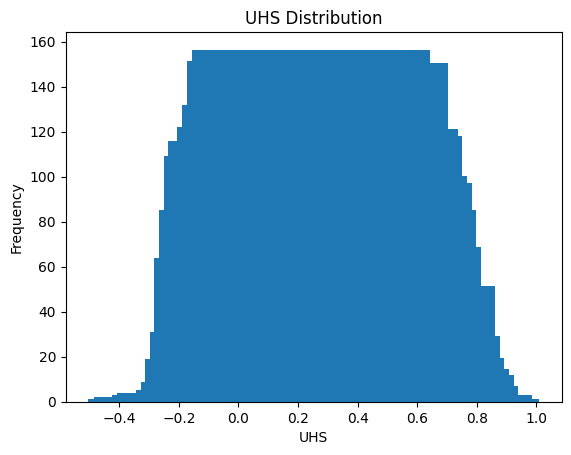

In [14]:
hist = UHS.reduceRegion(
    reducer=ee.Reducer.histogram(50),
    geometry=roi,
    scale=500,
    maxPixels=1e13
).getInfo()

bins = hist['UHS']['bucketMeans']
counts = hist['UHS']['histogram']

plt.figure()
plt.bar(bins, counts)
plt.title('UHS Distribution')
plt.xlabel('UHS')
plt.ylabel('Frequency')
plt.show()

**ภารกิจที่ 3: Sensitivity Analysis**

1. ปรับ weight ของ LST ±20%

เดิม: 0.40
เพิ่ม: 0.48
ลด: 0.32

2. วิเคราะห์แผนที่ (Sensitivity Map)

สีแดง = sensitive สูง
สีขาว = stable

12 — SENSITIVITY

In [15]:
UHS_high = (lst_n.multiply(0.48)
            .add(air_n.multiply(0.2))
            .add(ndbi_n.multiply(0.2))
            .subtract(ndvi_n.multiply(0.15))
            .subtract(ndwi_n.multiply(0.05)))

UHS_low = (lst_n.multiply(0.32)
           .add(air_n.multiply(0.2))
           .add(ndbi_n.multiply(0.2))
           .subtract(ndvi_n.multiply(0.15))
           .subtract(ndwi_n.multiply(0.05)))

diff = UHS_high.subtract(UHS_low)

Map.addLayer(diff, {
    'min':-0.2,'max':0.2,
    'palette':['blue','white','red']
}, 'Sensitivity')

Map

Map(center=[13.921145528717187, 100.3968564546895], controls=(WidgetControl(options=['position', 'transparent_…

**สรุป**

โมเดล Urban Heat Stress (UHS) นี้สามารถแสดง spatial distribution
ของความร้อนในเมือง โดยใช้หลายปัจจัยร่วมกัน ได้แก่ LST, Air Temperature,
NDBI, NDVI และ NDWI พร้อมทั้งมีการทำ normalization และ weighted analysis

โมเดลได้รับการตรวจสอบด้วย Pearson correlation เทียบกับ UHII
และมีการวิเคราะห์ sensitivity เพื่อประเมินความเสถียรของโมเดล

จุดแข็ง:
- ใช้ข้อมูลหลายแหล่ง (multi-source)
- มีทั้ง validation และ sensitivity analysis

จุดอ่อน:
- ไม่มี ground truth โดยตรง
- การกำหนด weight เป็นแบบ expert-based (ไม่ใช่ AHP)

In [16]:
# ==============================
# STEP 12 — EXPORT (GeoTIFF)
# ==============================

# export UHS (โมเดลหลัก)
task_uhs = ee.batch.Export.image.toDrive(
    image=UHS,
    description='UHS_Nonthaburi_2020',
    folder='GEE_EXPORT',
    fileNamePrefix='UHS_2020',
    region=roi.geometry(),
    scale=1000,
    maxPixels=1e13,
    fileFormat='GeoTIFF'
)
task_uhs.start()


# export UHII (validation data)
task_uhii = ee.batch.Export.image.toDrive(
    image=uhii,
    description='UHII_Nonthaburi_2020',
    folder='GEE_EXPORT',
    fileNamePrefix='UHII_2020',
    region=roi.geometry(),
    scale=1000,
    maxPixels=1e13,
    fileFormat='GeoTIFF'
)
task_uhii.start()


# export Sensitivity
task_sens = ee.batch.Export.image.toDrive(
    image=diff,
    description='Sensitivity_Nonthaburi_2020',
    folder='GEE_EXPORT',
    fileNamePrefix='Sensitivity_2020',
    region=roi.geometry(),
    scale=1000,
    maxPixels=1e13,
    fileFormat='GeoTIFF'
)
task_sens.start()


print("Export started! ไปดูใน Google Drive → โฟลเดอร์ GEE_EXPORT")

Export started! ไปดูใน Google Drive → โฟลเดอร์ GEE_EXPORT
